####  학습목표
- 시각화 패키지 folium , plotly
- 웹 시각화     streamlit
- LLM 가상환경구축( feat. vscode)

In [3]:
import numpy  as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import json   

# warning 제거
import warnings
warnings.filterwarnings('ignore')

# version check 
print('numpy  version - ' , np.__version__)
print('pandas version - ' , pd.__version__)

# 데이터 정보 출력 함수 
def aryInfo(ary) : 
    print('type - ' , type(ary)) 
    print('shape - ' , ary.shape)
    print('ndim  - ' , ary.ndim)
    print('dtype - ' , ary.dtype)
    print()
    print('data  -')
    print(ary) 
    
def seriesInfo(s) :
    print('type   - ' , type(s)) 
    print('index  - ' , s.index)
    print('values - ' , s.values)
    print('dtype  - ' , s.dtype)
    print()
    print('data   - ')
    print(s) 

def frmInfo(frm) :
    print('type    - ' , type(frm))
    print('shape   - ' , frm.shape)
    print('ndim    - ' , frm.ndim)
    print('row idx - ' , frm.index , type(frm.index))
    print('col idx - ' , frm.columns , type(frm.columns))
    print('values  - ' , type(frm.values))
    print(frm.values)
    print('data - ') 
    print(frm)


numpy  version -  2.1.3
pandas version -  2.2.3


In [4]:
%matplotlib inline

# 한글 폰트 문제 해결
import platform
from matplotlib import font_manager, rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~') 


# 차트 축 <- 음수 부호 지원
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False    

- 지도 시각화 : folium

In [10]:
import folium as g 

In [15]:
map = g.Map(location=[37.5574771, 127.0020518])

g.Marker([37.5574771, 127.0020518] , popup='동국대학교').add_to(map) 
g.CircleMarker([37.5574771, 127.0020518], 
               radius=50,
               color = 'red').add_to(map)
map

In [17]:
seoulUniFrm = pd.read_excel('./data/서울지역 대학교 위치.xlsx' , 
                       index_col = 0)
seoulUniFrm.head()

,위도,경도
KAIST 서울캠퍼스,37.592573,127.046737
KC대학교,37.548345,126.854797
가톨릭대학교(성신교정),37.585922,127.004328
가톨릭대학교(성의교정),37.499623,127.006065
감리교신학대학교,37.567645,126.961610


In [20]:
map = g.Map(location=[37.5574771, 127.0020518])

for name in seoulUniFrm.index : 
    # print(name)
    lat = seoulUniFrm.loc[name, '위도']
    lng = seoulUniFrm.loc[name, '경도']
    g.Marker([lat, lng], popup=name).add_to(map)

map

- plotly

In [22]:
import plotly.express as px

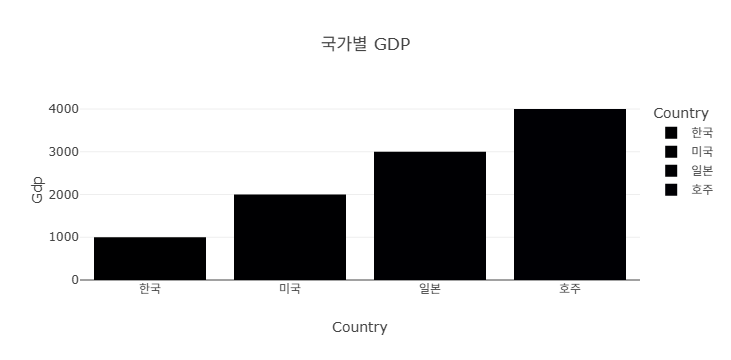

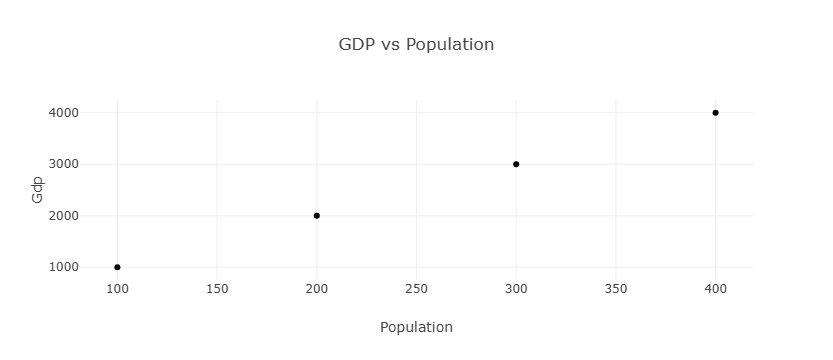

In [27]:
# 가 데이터
frm = pd.DataFrame({
    'Country' : ['한국', '미국', '일본', '호주'],
    'Gdp' : [1000, 2000, 3000, 4000],
    'Population' :[100, 200, 300, 400]
})

fig = px.bar(frm, x='Country', y='Gdp', title='국가별 GDP', color='Country')
fig.show()

fig02 = px.scatter(frm, x='Population', y='Gdp', hover_name='Country', title='GDP vs Population')
fig02.show()